In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import matplotlib
import seaborn as sns
import copy
import pickle
import warnings
warnings.filterwarnings('ignore')
import shap
from models import *
from utilities import *

In [19]:
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42 
matplotlib.rc('font', family='sans-serif') 
matplotlib.rc('font', serif='Helvetica Neue') 

In [20]:
##########################################################################################################

In [21]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("Eager mode:", tf.executing_eagerly())
print("GPUs:", tf.config.list_physical_devices('GPU'))

TF version: 2.15.0
Eager mode: True
GPUs: []


In [22]:
# shap.explainers._deep.deep_tf.op_handlers["AddV2"] = shap.explainers._deep.deep_tf.passthrough 
# shap.explainers._deep.deep_tf.op_handlers["FusedBatchNormV3"] = shap.explainers._deep.deep_tf.passthrough

In [23]:
################### data import ###############

In [24]:
data_dir = '../results/data/'
data_copy = pd.read_pickle(data_dir + 'LSTM_processed_data_dy_filter.pkl')
ba_copy = pd.read_pickle(data_dir + 'LSTM_processed_data_ba_filter.pkl')

In [25]:
ctxn = read_sas('../data/Apply_MI_Zheng_2023_01/ctxn.sas7bdat')
ids = list(ctxn['SCCRIP_ID'].unique())
data_copy = data_copy[~data_copy['SCCRIP_ID'].isin(ids)]
ba_copy = ba_copy[~ba_copy['SCCRIP_ID'].isin(ids)]

In [26]:
data_copy['Id_encoded'], uniques = pd.factorize(data_copy['SCCRIP_ID'])
mapping_dict = {value: index for index, value in enumerate(uniques)}

In [27]:
ba_copy['Id_encoded'] = ba_copy['SCCRIP_ID'].map(mapping_dict)
ba_copy = ba_copy[ba_copy['Id_encoded'].notna()]
ba_copy = ba_copy.drop_duplicates(subset='SCCRIP_ID', keep='last')
ba_copy.drop('SCCRIP_ID', inplace=True, axis=1)

In [28]:
ba_copy = ba_copy.fillna(0)
data_copy = data_copy.fillna(0)

In [29]:
with open(data_dir +  'SCCRIP_ID_dict.pkl', 'wb') as f:
    pickle.dump(mapping_dict, f)

In [30]:
len(data_copy.SCCRIP_ID.unique())

1045

In [31]:
feature_dy = data_copy.drop(['HU_status','Id_encoded','SCCRIP_ID'],axis=1).columns
feature_ba = ba_copy.drop(['Id_encoded'], axis=1).columns

In [32]:
################ data process ##################

In [33]:
seq_length = 5

In [34]:
sequences, seq_ba, labels, date,  y_target = create_dataset(data_copy, ba_copy, seq_length, mapping_dict)
sequences_copy, seq_ba_copy, labels_copy, date_copy, y_target_copy = shuffle_dataset(sequences, seq_ba, labels, date, y_target)
X, y, X_bg, dt, ls, seq_map = create_sequences_with_background(sequences_copy, labels_copy, seq_ba_copy, date_copy,y_target_copy, seq_length)
X_normalized, X_bg_normalized = normalize_X(X, X_bg)

In [35]:
(X_train,X_val,X_test,
            X_bg_train,X_bg_val,X_bg_test,
            dt_train, dt_val, dt_test, 
            y_train,y_val,y_test,
            ls_train, ls_val, ls_test,
            seq_map_train, seq_map_val, seq_map_test) = split_dataset(X_normalized, X_bg_normalized,dt, y, ls, seq_map)


In [36]:
# Initialize the model class
combined_model = CombinedLSTMModel(seq_length=seq_length, n_features=int(X_train.shape[2]), bg_features=int(X_bg_train.shape[2]))

Model input shapes: (None, 5, 795) (None, 1, 25) (None, 1, 1)
Model: "CombinedLSTMModel"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_bg (InputLayer)       [(None, 1, 25)]              0         []                            
                                                                                                  
 input_dt (InputLayer)       [(None, 1, 1)]               0         []                            
                                                                                                  
 input_seq (InputLayer)      [(None, 5, 795)]             0         []                            
                                                                                                  
 bg_plus_dt (Concatenate)    (None, 1, 26)                0         ['input_bg[0][0]',            
                    

In [37]:
# Train the model
history = combined_model.train(
    X_train, X_bg_train, dt_train, y_train,
    X_val,   X_bg_val,   dt_val,   y_val,
    epochs=20, batch_size=64,
    checkpoint_path="../results/models/mix_best2.h5"
)

Epoch 1/20
162/162 [==============================] - ETA: 0s - loss: 228.3687 - mean_absolute_error: 11.3248
Epoch 1: val_loss improved from inf to 47.78485, saving model to ../results/models/mix_best2.h5
162/162 [==============================] - 7s 8ms/step - loss: 228.3687 - mean_absolute_error: 11.3248 - val_loss: 47.7849 - val_mean_absolute_error: 5.0479
Epoch 2/20
155/162 [===========================>..] - ETA: 0s - loss: 28.7026 - mean_absolute_error: 3.7904
Epoch 2: val_loss improved from 47.78485 to 25.02969, saving model to ../results/models/mix_best2.h5
162/162 [==============================] - 1s 6ms/step - loss: 28.2791 - mean_absolute_error: 3.7630 - val_loss: 25.0297 - val_mean_absolute_error: 3.4885
Epoch 3/20
159/162 [============================>.] - ETA: 0s - loss: 19.0068 - mean_absolute_error: 3.0586
Epoch 3: val_loss improved from 25.02969 to 17.68889, saving model to ../results/models/mix_best2.h5
162/162 [==============================] - 1s 6ms/step - loss: 1

In [38]:
# Load the model
combined_model.save("../results/models/mix_best2.h5")
combined_model.load("../results/models/mix_best2.h5")

In [39]:
# Make predictions on the test set
y_pred = combined_model.predict(X_test, X_bg_test, dt_test)

94/94 [==============================] - 0s 2ms/step


In [40]:
figure_dir = '../results/figures/mix/'
ensure_directory_exists(figure_dir)

Directory '../results/figures/mix/' already exists.


Mean Squared Error: 16.7419
Mean Absolute Error: 2.8105
R^2 Score: 0.8527
r: 0.9245


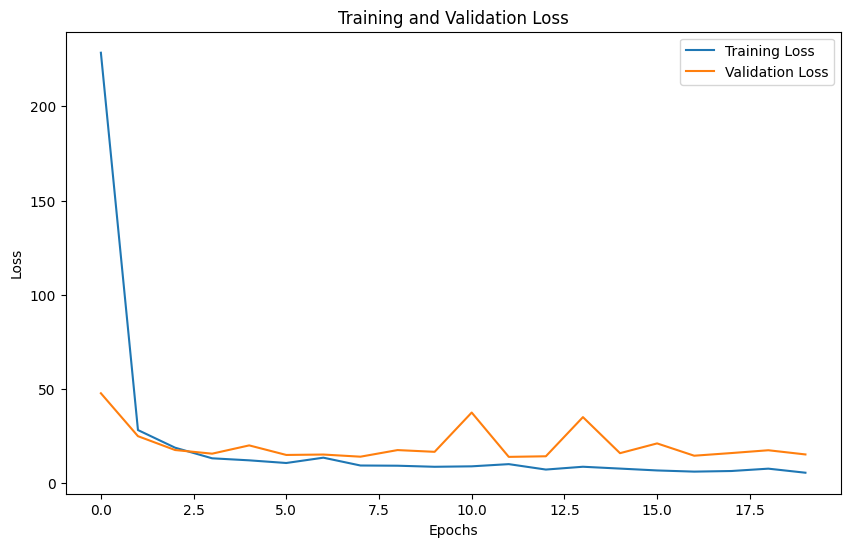

In [41]:
from scipy.stats import pearsonr
mse = mean_squared_error(y_test.flatten(), y_pred.flatten())
mae = mean_absolute_error(y_test.flatten(), y_pred.flatten())
r2 = r2_score(y_test.flatten(), y_pred.flatten())
r, _  = pearsonr(y_test.flatten(), y_pred.flatten())
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")
print(f"r: {r:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
# plt.savefig(figure_dir + 'LOSS.pdf')
plt.show()

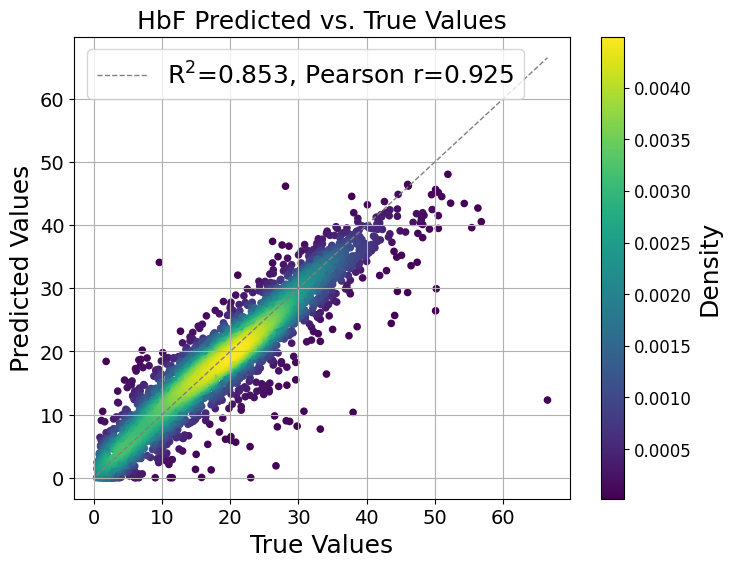

In [42]:
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list("custom_grey", ["#B3B3B3", "#4D4D4D"])

from scipy.stats import gaussian_kde, linregress

y_test = y_test.reshape(y_test.shape[0])
y_pred = y_pred.reshape(y_pred.shape[0])
xy = np.vstack([y_test, y_pred])
xy = np.nan_to_num(xy)
z = gaussian_kde(xy)(xy)

# Sort the points by density (optional, for better visualization)
idx = z.argsort()
y_test, y_pred, z = y_test[idx], y_pred[idx], z[idx]

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    y_test,
    y_pred,
    c=z,
    cmap='viridis',   # or 'plasma', 'inferno', etc.
    s=20,
    edgecolor=None
)

x_line = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(x_line, x_line, linestyle='dashed', color='grey', linewidth=1,  label=f'R$^2$={r2:.3f}, Pearson r={r:.3f}')
plt.xlabel('True Values', fontsize=18)
plt.ylabel('Predicted Values',fontsize=18)
# plt.xlim([0,80])
# plt.ylim([0,80])
cbar = fig.colorbar(sc)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Density', fontsize=18)
ax.tick_params(labelsize=14)

plt.title('HbF Predicted vs. True Values', fontsize=18)
plt.legend(fontsize=18)
plt.grid(True)
# plt.savefig(figure_dir+'dot_dot.pdf')

In [43]:
###############################################

In [50]:
r2 = []
# shap_impact = []
sequences, seq_ba, labels, date,  y_target = create_dataset(data_copy, ba_copy, seq_length, mapping_dict)
sequences_copy, seq_ba_copy, labels_copy, date_copy, y_target_copy = shuffle_dataset(sequences, seq_ba, labels, date, y_target)
X, y, X_bg, dt, ls, seq_map = create_sequences_with_background(sequences_copy, labels_copy, seq_ba_copy, date_copy,y_target_copy, seq_length)
X_normalized, X_bg_normalized = normalize_X(X, X_bg)
while len(r2) < 50:
    print (len(r2))
    (X_train,X_val,X_test,
                X_bg_train,X_bg_val,X_bg_test,
                dt_train, dt_val, dt_test, 
                y_train,y_val,y_test,
                ls_train, ls_val, ls_test,
                seq_map_train, seq_map_val, seq_map_test) = split_dataset(X_normalized, X_bg_normalized,dt, y, ls, seq_map)
    
    combined_model_l = CombinedLSTMModel(seq_length=seq_length, n_features=int(X_train.shape[2]), bg_features=int(X_bg_train.shape[2]), summary=False)
    
    history = combined_model_l.train(
    X_train, X_bg_train, dt_train, y_train,
    X_val,   X_bg_val,   dt_val,   y_val,
    epochs=20, batch_size=64,
    checkpoint_path="../results/models/Mix_best2_loop.h5")
    y_pred = combined_model_l.predict(X_test, X_bg_test, dt_test)
    r2_ = r2_score(y_test.flatten(), y_pred.flatten())
    if r2_ > 0:
        r2.append(r2_)

        # explainer = shap.GradientExplainer(combined_model_l.model, [X_test, X_bg_test, dt_test])
        # shap_values = explainer.shap_values([X_test, X_bg_test, dt_test])

        # shap_val_d = []
        # train_d = []

        # for i in range (5):
        #     shap_val_d.append(pd.DataFrame(shap_values[0][:,i,:,0], columns=feature_dy))
        #     train_d.append(pd.DataFrame(X_test[:,i,:],columns=feature_dy))
            
        # shap_val_b = pd.DataFrame(shap_values[1][:,0,:,0], columns=feature_ba)
        # train_b = pd.DataFrame(X_bg_test[:,0,:], columns=feature_ba)

        # impact_dy = []

        # for i in range(5):
        #     im = ABS_SHAP(shap_val_d[i], train_d[i])
        #     impact_dy.append(im)
            
        # impact_ba = ABS_SHAP(shap_val_b, train_b)

        # shap_impact.append((impact_dy, impact_ba))

20
Epoch 1/20
151/158 [===========================>..] - ETA: 0s - loss: 136.3078 - mean_absolute_error: 8.0837
Epoch 1: val_loss improved from inf to 62.91490, saving model to ../results/models/Mix_best2_loop.h5
158/158 [==============================] - 3s 8ms/step - loss: 132.1005 - mean_absolute_error: 7.9280 - val_loss: 62.9149 - val_mean_absolute_error: 4.9083
Epoch 2/20
151/158 [===========================>..] - ETA: 0s - loss: 19.8694 - mean_absolute_error: 3.2094
Epoch 2: val_loss improved from 62.91490 to 49.11710, saving model to ../results/models/Mix_best2_loop.h5
158/158 [==============================] - 1s 6ms/step - loss: 19.9464 - mean_absolute_error: 3.2113 - val_loss: 49.1171 - val_mean_absolute_error: 4.1488
Epoch 3/20
151/158 [===========================>..] - ETA: 0s - loss: 12.9046 - mean_absolute_error: 2.5588
Epoch 3: val_loss improved from 49.11710 to 34.65707, saving model to ../results/models/Mix_best2_loop.h5
158/158 [==============================] - 1s 6m

In [51]:
with open('../results/data/mix/r2_noCTXN.pkl','wb') as f:
    pickle.dump(r2,f)